In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#my file path = 'C:/Users/Prameel/Desktop/NASSCOM/NASSCOM-Training-/Project/AI_Student_performance_50000_with_Errors.csv'

df = pd.read_csv('C:/Users/Prameel/Desktop/NASSCOM/NASSCOM-Training-/Project/AI_Student_performance_50000_with_Errors.csv')

Understand the dataset

In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (51000, 16)


In [6]:
#view sample records
print(df.head())

   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001        Medical     Sophomore             3.192   
1      100002     Humanities     Sophomore             3.683   
2      100003           STEM        Senior             3.450   
3      100004        Medical      Freshman             2.878   
4      100005        Medical        Junior             3.915   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                7.78       Copywriting/Drafting                 Advanced   
1               22.29  Debugging/Troubleshooting             Intermediate   
2                3.57        Summarizing_Reading                 Beginner   
3               11.37       Copywriting/Drafting             Intermediate   
4               28.16                   Ideation                 Beginner   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               4              False                     7.77   
1               2     

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  51000 non-null  int64  
 1   Major_Category              51000 non-null  str    
 2   Year_of_Study               51000 non-null  str    
 3   Pre_Semester_GPA            49470 non-null  float64
 4   Weekly_GenAI_Hours          49476 non-null  float64
 5   Primary_Use_Case            51000 non-null  str    
 6   Prompt_Engineering_Skill    49470 non-null  str    
 7   Tool_Diversity              51000 non-null  int64  
 8   Paid_Subscription           51000 non-null  bool   
 9   Traditional_Study_Hours     49475 non-null  float64
 10  Perceived_AI_Dependency     51000 non-null  int64  
 11  Institutional_Policy        51000 non-null  str    
 12  Anxiety_Level_During_Exams  51000 non-null  int64  
 13  Post_Semester_GPA           51000 non-null

In [8]:
df.dtypes

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object

In [9]:
df.isnull().sum()

Student_ID                       0
Major_Category                   0
Year_of_Study                    0
Pre_Semester_GPA              1530
Weekly_GenAI_Hours            1524
Primary_Use_Case                 0
Prompt_Engineering_Skill      1530
Tool_Diversity                   0
Paid_Subscription                0
Traditional_Study_Hours       1525
Perceived_AI_Dependency          0
Institutional_Policy             0
Anxiety_Level_During_Exams       0
Post_Semester_GPA                0
Skill_Retention_Score         1522
Burnout_Risk_Level               0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

Student_ID                    0.000000
Major_Category                0.000000
Year_of_Study                 0.000000
Pre_Semester_GPA              3.000000
Weekly_GenAI_Hours            2.988235
Primary_Use_Case              0.000000
Prompt_Engineering_Skill      3.000000
Tool_Diversity                0.000000
Paid_Subscription             0.000000
Traditional_Study_Hours       2.990196
Perceived_AI_Dependency       0.000000
Institutional_Policy          0.000000
Anxiety_Level_During_Exams    0.000000
Post_Semester_GPA             0.000000
Skill_Retention_Score         2.984314
Burnout_Risk_Level            0.000000
dtype: float64

In [11]:
df.duplicated().sum()

636

In [12]:
df.drop_duplicates(inplace=True)
print(df)

       Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0          100001        Medical     Sophomore             3.192   
1          100002     Humanities     Sophomore             3.683   
2          100003           STEM        Senior             3.450   
3          100004        Medical      Freshman             2.878   
4          100005        Medical        Junior             3.915   
...           ...            ...           ...               ...   
50982      148706           STEM        Senior             2.246   
50984      118786           STEM      Freshman             3.067   
50987      133986        Medical     Sophomore             3.203   
50988      111626        Medical      Freshman             3.267   
50992      143512           STEM      Freshman             3.312   

       Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                    7.78       Copywriting/Drafting                 Advanced   
1                   2

In [13]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50364.000000,48834.000000,48840.000000,50364.000000,48840.000000,50364.000000,50364.000000,50364.000000,48842.000000
mean,124999.180208,3.198821,10.462221,3.000298,12.194850,3.002343,5.512310,3.238701,74.902015
std,14436.998487,0.392750,9.828805,1.411649,5.409213,1.414001,2.871882,0.431002,15.163235
min,100001.000000,1.415000,0.020000,1.000000,0.000000,1.000000,1.000000,1.077000,11.590000
25%,112498.750000,2.933000,4.870000,2.000000,9.300000,2.000000,3.000000,2.943000,64.870000
50%,124996.500000,3.203000,8.480000,3.000000,12.010000,3.000000,6.000000,3.248000,75.000000
75%,137505.250000,3.472000,13.550000,4.000000,14.720000,4.000000,8.000000,3.552000,85.200000
max,150000.000000,4.000000,149.811876,5.000000,99.654631,5.000000,10.000000,4.000000,199.825455


In [14]:
df.describe(include='object')

C:\Users\Prameel\AppData\Local\Temp\ipykernel_32016\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
count,50364,50364,50364,48834,50364,50364
unique,7,8,8,3,3,4
top,STEM,Sophomore,Summarizing_Reading,Intermediate,Strict_Ban,Low
freq,12700,12606,12450,19695,16869,20130


In [15]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


 Major_Category
<StringArray>
[   'Medical', 'Humanities',       'STEM',   'Business',    'MEDICAL',
 'HUMANITIES',   'BUSINESS']
Length: 7, dtype: str

 Year_of_Study
<StringArray>
[  'Sophomore',      'Senior',    'Freshman',      'Junior',    ' Senior ',
  ' Freshman ', ' Sophomore ',    ' Junior ']
Length: 8, dtype: str

 Primary_Use_Case
<StringArray>
[     'Copywriting/Drafting', 'Debugging/Troubleshooting',
       'Summarizing_Reading',                  'Ideation',
 'DEBUGGING/TROUBLESHOOTING',       'SUMMARIZING_READING',
      'COPYWRITING/DRAFTING',                  'IDEATION']
Length: 8, dtype: str

 Prompt_Engineering_Skill
<StringArray>
['Advanced', 'Intermediate', 'Beginner', nan]
Length: 4, dtype: str

 Institutional_Policy
<StringArray>
['Allowed_With_Disclosure', 'Strict_Ban', 'Allowed_With_Citation']
Length: 3, dtype: str

 Burnout_Risk_Level
<StringArray>
['High', 'Medium', 'Low', 'Unknown']
Length: 4, dtype: str


C:\Users\Prameel\AppData\Local\Temp\ipykernel_32016\3835539417.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [16]:
# checking missing values again
print(df.isnull().sum())

Student_ID                       0
Major_Category                   0
Year_of_Study                    0
Pre_Semester_GPA              1530
Weekly_GenAI_Hours            1524
Primary_Use_Case                 0
Prompt_Engineering_Skill      1530
Tool_Diversity                   0
Paid_Subscription                0
Traditional_Study_Hours       1524
Perceived_AI_Dependency          0
Institutional_Policy             0
Anxiety_Level_During_Exams       0
Post_Semester_GPA                0
Skill_Retention_Score         1522
Burnout_Risk_Level               0
dtype: int64


In [24]:
print(df.dtypes)

Student_ID                        str
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


In [25]:
#stduent id  is a identifier
df['Student_ID'] = df['Student_ID'].astype(str)
print(df['Student_ID'].dtype)

str


In [23]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
print(df[col])

0          High
1        Medium
2        Medium
3        Medium
4          High
          ...  
50982      High
50984      High
50987      High
50988    Medium
50992       Low
Name: Burnout_Risk_Level, Length: 50364, dtype: str


C:\Users\Prameel\AppData\Local\Temp\ipykernel_32016\3489182982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [26]:
df['Major_Category'] = (
    df['Major_Category']
    .str.strip()
    .str.title()
)

In [27]:
df['Primary_Use_Case'] = (
    df['Primary_Use_Case']
    .str.strip()
    .str.title()
)

In [28]:
df['Prompt_Engineering_Skill'] = (
    df['Prompt_Engineering_Skill']
    .str.strip()
    .str.title()
)

In [29]:
print(df['Major_Category'].unique())
print(df['Primary_Use_Case'].unique())

<StringArray>
['Medical', 'Humanities', 'Stem', 'Business']
Length: 4, dtype: str
<StringArray>
[     'Copywriting/Drafting', 'Debugging/Troubleshooting',
       'Summarizing_Reading',                  'Ideation']
Length: 4, dtype: str


In [30]:
print(df.duplicated().sum())

88


In [31]:
df.drop_duplicates(inplace=True)

In [32]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50276.000000,50276.000000,50276.000000,50276.000000,50276.000000,50276.000000,50276.000000,50276.000000
mean,3.198877,10.402991,3.000537,12.188863,3.002248,5.511974,3.238674,74.903826
std,0.386741,9.689449,1.411546,5.329236,1.414050,2.872112,0.431043,14.932749
min,1.415000,0.020000,1.000000,0.000000,1.000000,1.000000,1.077000,11.590000
25%,2.943000,4.970000,2.000000,9.390000,2.000000,3.000000,2.943000,65.240000
50%,3.203000,8.480000,3.000000,12.010000,3.000000,6.000000,3.248000,75.000000
75%,3.462000,13.320000,4.000000,14.620000,4.000000,8.000000,3.552000,84.850000
max,4.000000,149.811876,5.000000,99.654631,5.000000,10.000000,4.000000,199.825455


In [33]:
Q1 = df['Skill_Retention_Score'].quantile(0.25)
Q3 = df['Skill_Retention_Score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Skill_Retention_Score'] < lower) |
    (df['Skill_Retention_Score'] > upper)
]

print(len(outliers))

366


In [34]:
df = df[
    (df['Skill_Retention_Score'] >= lower) &
    (df['Skill_Retention_Score'] <= upper)
]

In [35]:
df[
    (df['Pre_Semester_GPA'] < 0) |
    (df['Pre_Semester_GPA'] > 4)
]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


In [36]:
df[
    (df['Post_Semester_GPA'] < 0) |
    (df['Post_Semester_GPA'] > 4)
]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


In [37]:
df['Weekly_GenAI_Hours'].describe()

count    49910.000000
mean        10.402174
std          9.704749
min          0.020000
25%          4.970000
50%          8.480000
75%         13.310000
max        149.811876
Name: Weekly_GenAI_Hours, dtype: float64

In [38]:
df['Traditional_Study_Hours'].describe()

count    49910.000000
mean        12.186855
std          5.320211
min          0.000000
25%          9.390000
50%         12.010000
75%         14.620000
max         99.654631
Name: Traditional_Study_Hours, dtype: float64

In [39]:
for col in [
    'Major_Category',
    'Prompt_Engineering_Skill',
    'Primary_Use_Case'
]:
    print("\n", col)
    print(df[col].value_counts())


 Major_Category
Major_Category
Stem          12594
Humanities    12493
Business      12420
Medical       12403
Name: count, dtype: int64

 Prompt_Engineering_Skill
Prompt_Engineering_Skill
Intermediate    21021
Beginner        19219
Advanced         9670
Name: count, dtype: int64

 Primary_Use_Case
Primary_Use_Case
Summarizing_Reading          12601
Copywriting/Drafting         12485
Debugging/Troubleshooting    12416
Ideation                     12408
Name: count, dtype: int64


In [40]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 49910 entries, 0 to 50992
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  49910 non-null  str    
 1   Major_Category              49910 non-null  str    
 2   Year_of_Study               49910 non-null  str    
 3   Pre_Semester_GPA            49910 non-null  float64
 4   Weekly_GenAI_Hours          49910 non-null  float64
 5   Primary_Use_Case            49910 non-null  str    
 6   Prompt_Engineering_Skill    49910 non-null  str    
 7   Tool_Diversity              49910 non-null  int64  
 8   Paid_Subscription           49910 non-null  bool   
 9   Traditional_Study_Hours     49910 non-null  float64
 10  Perceived_AI_Dependency     49910 non-null  int64  
 11  Institutional_Policy        49910 non-null  str    
 12  Anxiety_Level_During_Exams  49910 non-null  int64  
 13  Post_Semester_GPA           49910 non-null  flo

In [41]:
print(df.isnull().sum())

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


In [42]:
print(df.duplicated().sum())

0


In [43]:
print(df.shape)

(49910, 16)


In [44]:
df.to_csv(
    "AI_Student_Performance_Cleaned.csv",
    index=False
)

EDA: the goal is " what stories is the data is telling us?"

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,49910.0,3.198912,0.386719,1.415,2.943,3.203,3.462,4.000000
Weekly_GenAI_Hours,49910.0,10.402174,9.704749,0.020,4.970,8.480,13.310,149.811876
Tool_Diversity,49910.0,3.000341,1.411398,1.000,2.000,3.000,4.000,5.000000
Traditional_Study_Hours,49910.0,12.186855,5.320211,0.000,9.390,12.010,14.620,99.654631
Perceived_AI_Dependency,49910.0,3.002464,1.414034,1.000,2.000,3.000,4.000,5.000000
Anxiety_Level_During_Exams,49910.0,5.511481,2.872343,1.000,3.000,6.000,8.000,10.000000
Post_Semester_GPA,49910.0,3.238731,0.430890,1.077,2.943,3.248,3.552,4.000000
Skill_Retention_Score,49910.0,74.841482,13.910119,35.850,65.340,75.000,84.780,100.000000


lets look at mean, median,min,max,std , what is the average GPA ? Average GenAI usage? Average retenion score?

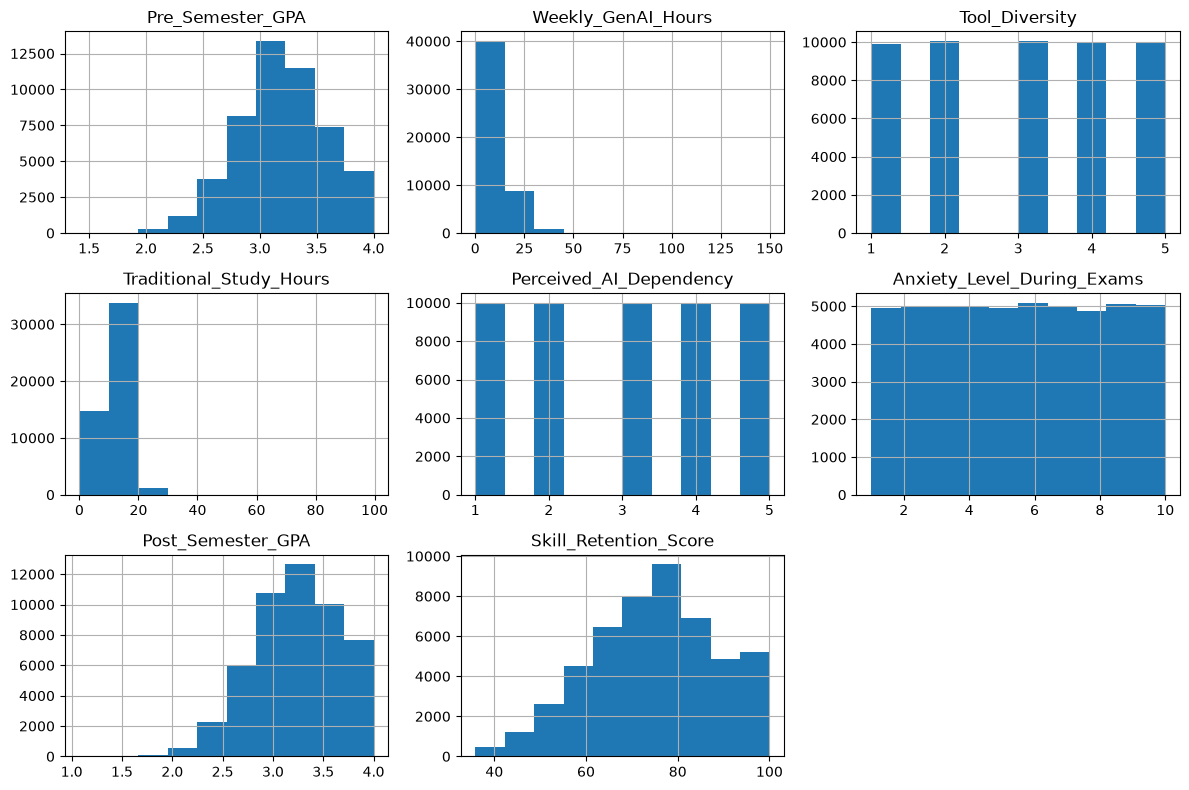

In [46]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Observe : normal distibution? skewed? Mutiple peaks? 


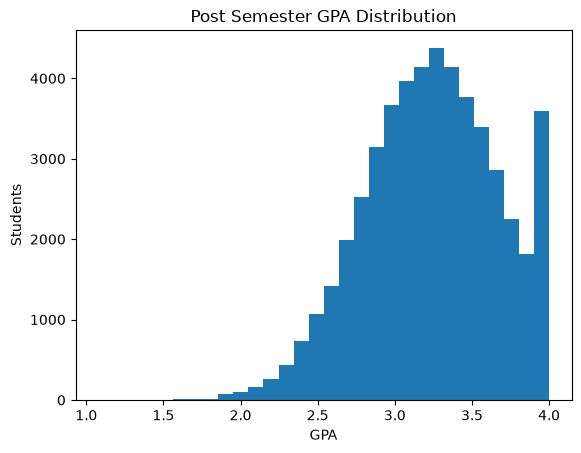

In [47]:
plt.hist(df['Post_Semester_GPA'], bins=30)
plt.title("Post Semester GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Students")
plt.show()

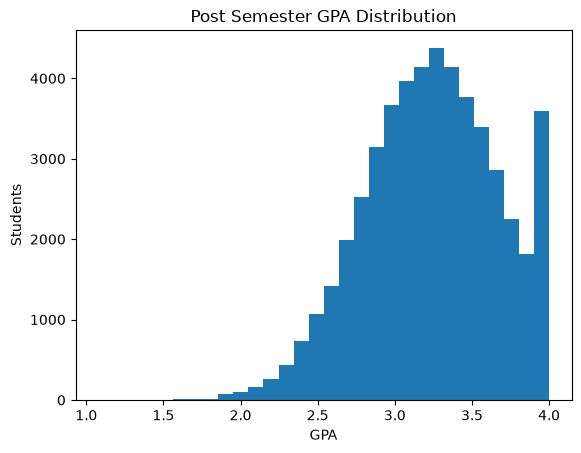

In [48]:
plt.hist(df['Post_Semester_GPA'], bins=30)
plt.title("Post Semester GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Students")
plt.show()

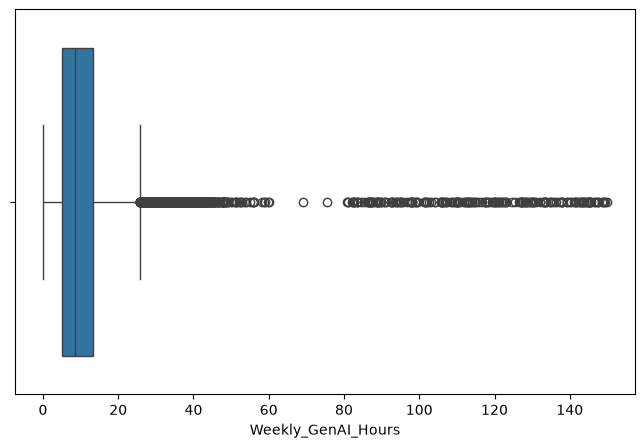

In [49]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Weekly_GenAI_Hours'])
plt.show()

In [50]:
corr = df.select_dtypes(include=['int64','float64']).corr()

corr

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Pre_Semester_GPA,1.000000,0.001622,0.001581,-0.000667,-0.001020,-0.000508,0.006998,0.006190
Weekly_GenAI_Hours,0.001622,1.000000,0.006985,-0.006299,-0.004982,0.005590,0.000074,0.000017
Tool_Diversity,0.001581,0.006985,1.000000,0.009669,-0.004900,-0.002796,-0.007319,-0.004547
Traditional_Study_Hours,-0.000667,-0.006299,0.009669,1.000000,0.002143,0.002833,-0.004484,0.001578
Perceived_AI_Dependency,-0.001020,-0.004982,-0.004900,0.002143,1.000000,0.003345,-0.002334,-0.001334
Anxiety_Level_During_Exams,-0.000508,0.005590,-0.002796,0.002833,0.003345,1.000000,-0.006706,-0.001007
Post_Semester_GPA,0.006998,0.000074,-0.007319,-0.004484,-0.002334,-0.006706,1.000000,0.000566
Skill_Retention_Score,0.006190,0.000017,-0.004547,0.001578,-0.001334,-0.001007,0.000566,1.000000


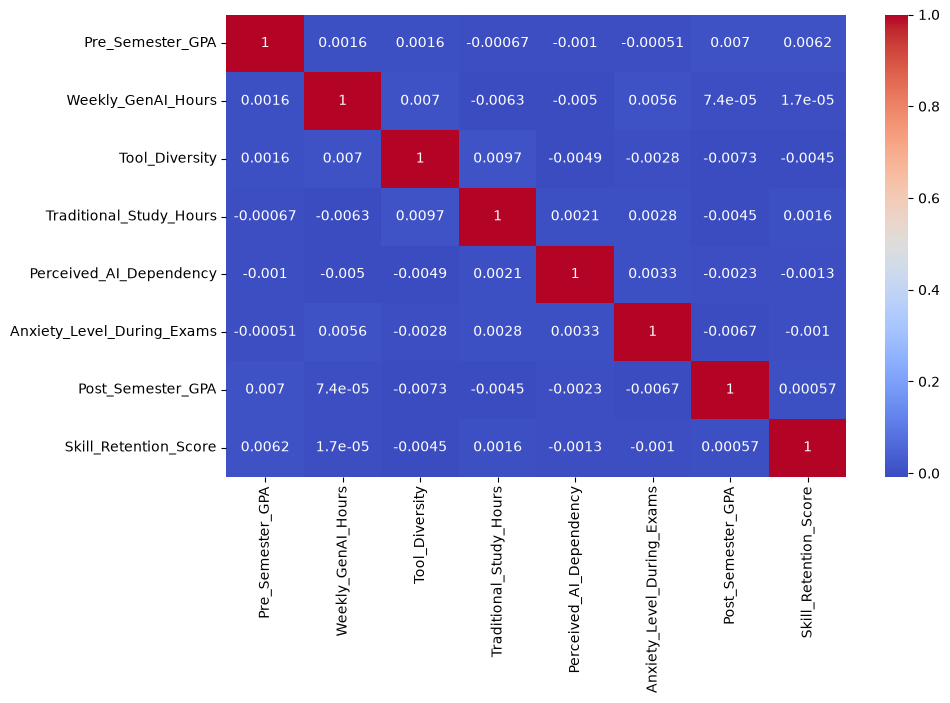

In [51]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

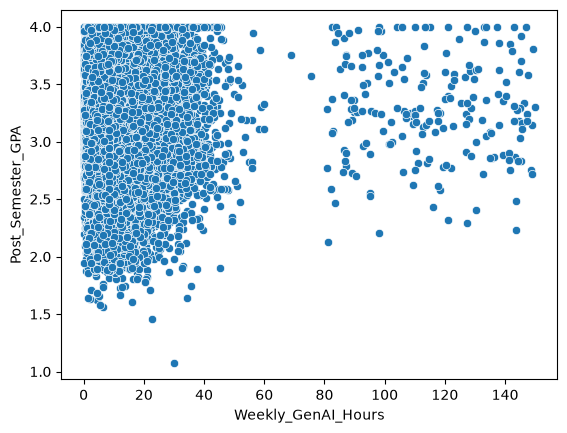

In [52]:
sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

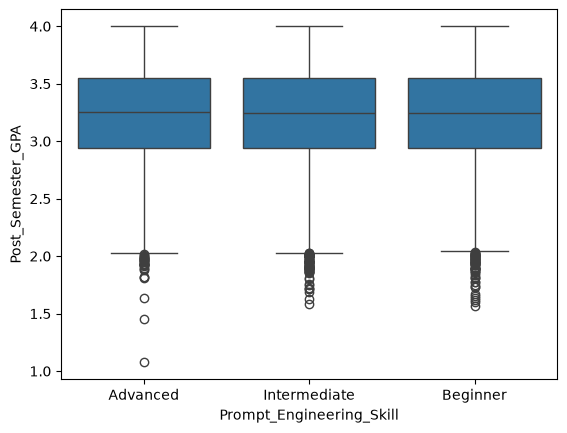

In [53]:
sns.boxplot(
    x='Prompt_Engineering_Skill',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

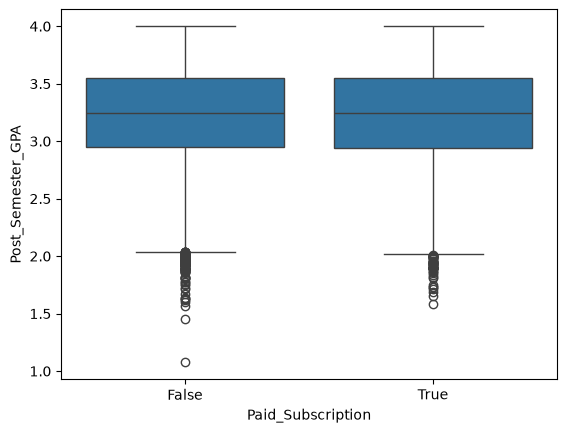

In [54]:
sns.boxplot(
    x='Paid_Subscription',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

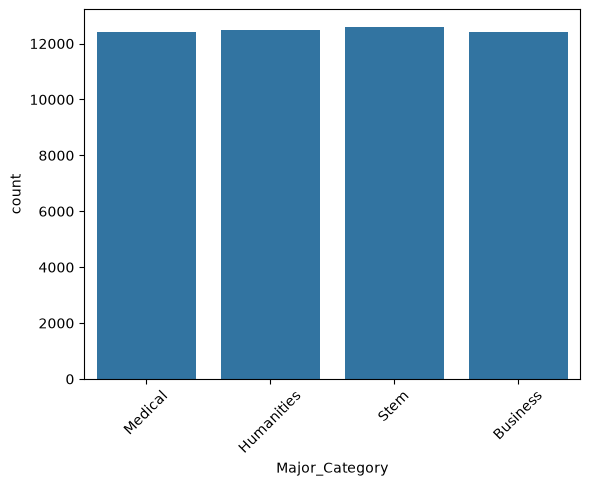

In [55]:
sns.countplot(
    x='Major_Category',
    data=df
)

plt.xticks(rotation=45)
plt.show()

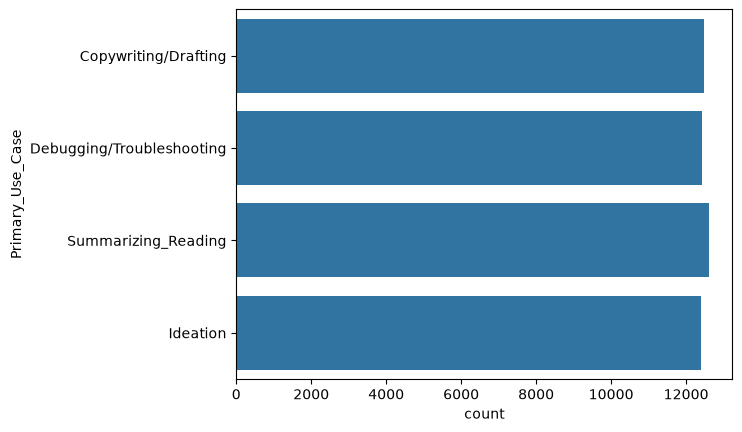

In [56]:
sns.countplot(
    y='Primary_Use_Case',
    data=df
)

plt.show()

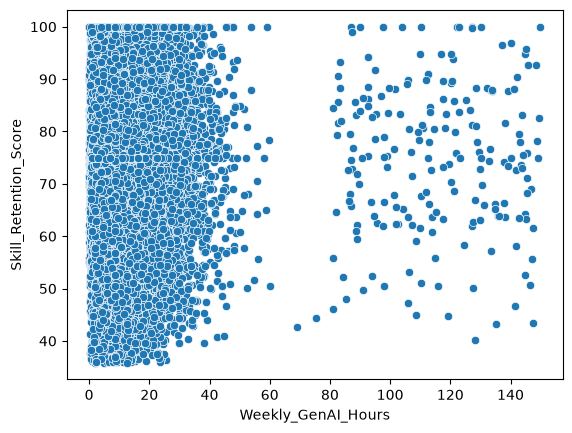

In [57]:
sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Skill_Retention_Score',
    data=df
)

plt.show()

Feature Engineering

In [59]:
X = df.drop('Post_Semester_GPA', axis=1)
y = df['Post_Semester_GPA']

In [60]:
X = X.drop('Student_ID', axis=1)

In [61]:
print(X.dtypes)

Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


In [62]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [63]:
X.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,Major_Category_Humanities,Major_Category_Medical,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Disclosure,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Burnout_Risk_Level_Unknown
0,3.192,7.78,4,False,7.77,1,1,83.95,False,True,...,False,False,False,False,False,True,False,False,False,False
1,3.683,22.29,2,False,17.04,3,4,81.22,True,False,...,True,False,False,False,True,True,False,False,True,False
2,3.450,3.57,3,False,9.38,1,3,100.00,False,False,...,False,False,True,True,False,False,True,False,True,False
3,2.878,11.37,1,True,12.01,1,10,72.90,False,True,...,False,False,False,False,True,True,False,False,True,False
4,3.915,28.16,5,False,6.63,1,9,75.00,False,True,...,False,True,False,True,False,False,False,False,False,False


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
print(X_train.shape)
print(X_test.shape)

(39928, 24)
(9982, 24)


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [68]:
print(X_train_scaled[:5])

[[-2.06051303 -0.82192599  1.41790057 -0.65136052 -0.07249993 -0.71211251
  -0.17638185 -1.35908656 -0.57954816  1.73995286 -0.57920113  1.7347155
  -0.5762706  -0.58286439  1.72893311 -0.57368709 -0.57993376 -0.79061446
   1.17072587  1.41695411 -0.71084238 -0.81108825  1.22783047 -0.06500271]
 [-0.61867023  1.08831539 -0.70828465 -0.65136052 -0.77744192  0.70096446
   0.86876897  0.3385484  -0.57954816 -0.57472821 -0.57920113 -0.5764634
  -0.5762706   1.71566494 -0.57839137 -0.57368709 -0.57993376  1.264839
  -0.85417093  1.41695411 -0.71084238 -0.81108825 -0.81444468 -0.06500271]
 [-0.22145414  2.63877575  0.70917216  1.5352481  -0.83035981 -0.71211251
   1.21715258 -0.38325231 -0.57954816 -0.57472821  1.72651598 -0.5764634
   1.73529587 -0.58286439 -0.57839137  1.74311053 -0.57993376 -0.79061446
  -0.85417093 -0.70573916 -0.71084238  1.23291147 -0.81444468 -0.06500271]
 [-0.28077862 -0.62708756 -0.70828465  1.5352481  -0.01580218  1.40750294
  -0.17638185 -0.45953434 -0.57954816  1

In [69]:
from sklearn.linear_model import LinearRegression

In [70]:
model = LinearRegression()

In [71]:
model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [72]:
y_pred = model.predict(X_test_scaled)

In [73]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.18755239933451814


In [74]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)

R²: -0.001135578650935054


In [75]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print(
    r2_score(y_test, ridge_pred)
)

-0.0011355290046131117


In [76]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print(
    r2_score(y_test, lasso_pred)
)

-1.6534133662204908e-06
